This code preprocesses the clinical+gex corrected data, train and validate a logistic regression, save the best model for explanability.<br>
This pipeline contains data leakage on the gene columns because we select best 20 genes before splitting data into train and test set.<br>
However, the preprocessing data pipeline is fitted only on train set, then transformed on test set, so no data leakage on this part.

Import libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.metrics import f1_score, roc_auc_score
import shap

Load data

In [19]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/tcga_gdc.csv", low_memory=False)

print(clinical_gex.shape)
clinical_gex.head()

(292, 40815)


,SAMPLE_ID,A1BG,NAT2,ADA,CDH2,AKT3,GAGE12F,LINC02584,POU5F1P5,POU5F1P6,...,PATH_N_STAGE,PATH_STAGE,PATH_T_STAGE,PRIMARY_SITE_PATIENT,PRIOR_MALIGNANCY,PRIOR_TREATMENT,RACE,SEX,YEAR_OF_DIAGNOSIS,os_label
0,TCGA-3N-A9WB-06A,0.2460,0.0000,12.4774,0.0358,35.3259,0.0,0.0000,0.0,0.0621,...,NX,Stage IA,T1a,Trunk,False,False,WHITE,Male,2012.0,0
1,TCGA-3N-A9WD-06A,0.3119,0.0000,10.5382,0.4456,13.0935,0.0,0.6626,0.0,0.0840,...,N1a,Stage IIIA,T2a,Other Specify,False,False,WHITE,Male,2013.0,0
2,TCGA-BF-A1PX-01A,0.1272,0.0305,14.9661,1.1447,10.2892,0.0,0.0780,0.0,0.2768,...,N2a,Stage IIIB,T4b,Trunk,False,False,WHITE,Male,2010.0,0
3,TCGA-D3-A1Q1-06A,0.8970,0.0000,51.9998,0.1713,72.1101,0.0,0.0000,0.0,0.1782,...,N3,Stage IIIC,T1b,Extremities,False,False,WHITE,Female,2004.0,0
4,TCGA-D3-A1Q3-06A,0.2530,0.0000,12.0290,23.6309,65.5314,0.0,0.0000,0.0,0.2222,...,N0,Stage IIC,T4b,Extremities,False,True,WHITE,Male,2001.0,0


Grouping features based on type

In [ ]:
# Clinical feature groups
clinical_categorical_cols = ['ETHNICITY', 'ICD_10', 'MORPHOLOGY', 'SAMPLE_TYPE',
                            'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_STAGE', 'PATH_T_STAGE',
                            'PRIMARY_SITE_PATIENT', 'PRIOR_MALIGNANCY', 'PRIOR_TREATMENT', 'RACE',
                            'SEX']
clinical_numeric_col    = ['AGE', 'TMB_NONSYNONYMOUS']
clinical_remaining_cols = ['PATIENT_ID', 'SAMPLE_ID', 'YEAR_OF_DIAGNOSIS', 'os_label']

CLINICAL_COLS = (clinical_categorical_cols + clinical_numeric_col + clinical_remaining_cols)

GEX_COLS = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print('Original clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS)} = {len(CLINICAL_COLS)+len(GEX_COLS)}')

Original clinical_gex features:
clinical + gex = 19 + 40796 = 40815


Feature selection on gex columns

In [ ]:
clinical_gex.columns = clinical_gex.columns.str.strip()
y = clinical_gex['os_label']

pre_selection_pipe = Pipeline([
    ('threshold', VarianceThreshold(threshold=0.1)),
    ('seleckbest', SelectKBest(f_classif, k=20)),
])

gex_cols_selected = clinical_gex[GEX_COLS]
gex_cols_selected = pre_selection_pipe.fit_transform(gex_cols_selected, y)
gex_cols_selected = pre_selection_pipe.get_feature_names_out()
gex_cols_selected

array(['NR1H3', 'C1DP5', 'PKIG', 'GBP4', 'HAPLN3', 'SAMD9L', 'MCOLN2',
       'FGFR1OP2', 'GIMAP2', 'HEXD', 'IRF2', 'VPS13C', 'GRIPAP1',
       'PARP11', 'RNF213', 'SP100', 'STAT1', 'UBA7', 'NMI', 'CLEC2B'],
      dtype=object)

In [ ]:
features_after_vt = pre_selection_pipe['threshold'].get_feature_names_out()
f_values = pre_selection_pipe['seleckbest'].scores_

f_series = pd.Series(f_values, index=features_after_vt).sort_values(ascending=False)
print("Top 20 genes by ANOVA F-value:")
print(f_series.head(20).to_string())

# fig, ax = plt.subplots(figsize=(8, 4),  dpi=150)
# sns.kdeplot(f_values, ax=ax, fill=True)
# ax.set_xlabel('ANOVA F-value')
# ax.set_ylabel('Density')
# ax.set_title('Distribution of ANOVA F-values across GEx features')
# plt.tight_layout()
# plt.show()

Top 20 genes by ANOVA F-value:
C1DP5       27.580714
GRIPAP1     26.083130
SAMD9L      24.549774
PARP11      24.532341
VPS13C      24.522949
CLEC2B      24.308936
SP100       24.099436
STAT1       23.643330
UBA7        23.345260
HEXD        23.328851
MCOLN2      23.053923
GBP4        23.014409
IRF2        22.645923
FGFR1OP2    22.158918
PKIG        22.063798
NMI         22.003673
GIMAP2      21.915664
RNF213      21.630687
NR1H3       21.391167
HAPLN3      21.114088


Split train & test set

In [22]:
from sklearn.model_selection import train_test_split

x = clinical_gex[clinical_categorical_cols + clinical_numeric_col + list(gex_cols_selected)]
print(f'Dropped {len(clinical_remaining_cols)} clinical cols, {x.shape} remaining')
x.head()

Dropped 4 clinical cols, (292, 35) remaining


,ETHNICITY,ICD_10,MORPHOLOGY,SAMPLE_TYPE,PATH_M_STAGE,PATH_N_STAGE,PATH_STAGE,PATH_T_STAGE,PRIMARY_SITE_PATIENT,PRIOR_MALIGNANCY,...,IRF2,VPS13C,GRIPAP1,PARP11,RNF213,SP100,STAT1,UBA7,NMI,CLEC2B
0,NOT HISPANIC OR LATINO,C44.5,8720/3,Metastatic,M0,NX,Stage IA,T1a,Trunk,False,...,17.7057,7.0468,21.8866,0.5653,31.5646,15.7138,60.1739,8.3923,10.1554,32.5860
1,NOT HISPANIC OR LATINO,C77.0,8720/3,Metastatic,M0,N1a,Stage IIIA,T2a,Other Specify,False,...,37.6755,5.9801,21.5384,3.4199,10.4893,21.5497,106.8458,29.4777,16.4445,6.0204
2,NOT HISPANIC OR LATINO,C44.9,8720/3,Primary Tumor,M0,N2a,Stage IIIB,T4b,Trunk,False,...,37.1413,3.3892,22.1549,2.8979,22.8296,12.3849,185.0702,34.9621,15.8841,21.4263
3,NOT HISPANIC OR LATINO,C77.9,8720/3,Metastatic,M0,N3,Stage IIIC,T1b,Extremities,False,...,21.7783,6.7240,10.7274,7.6824,12.5778,10.8004,37.8219,5.4021,17.5948,2.1399
4,NOT HISPANIC OR LATINO,C77.9,8720/3,Metastatic,M0,N0,Stage IIC,T4b,Extremities,False,...,61.7814,26.8226,31.0825,12.0707,44.3646,25.4877,290.7192,29.7823,6.2435,9.9401


In [23]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
os_label
0    172
1    120
Name: count, dtype: int64


Preprocessing Pipeline

In [24]:
ordinal_categorical_cols = ['PATH_T_STAGE', 'PATH_N_STAGE', 'PATH_M_STAGE', 'PATH_STAGE']
nominal_categorical_cols = [c for c in clinical_categorical_cols if c not in ordinal_categorical_cols]

# X/NOS = not assessed / not otherwise specified, placed last
T_STAGE_ORDER = ['Tis', 'T0', 'T1', 'T1a', 'T1b', 'T2', 'T2a', 'T2b', 'T3', 'T3a', 'T3b', 'T4', 'T4a', 'T4b', 'TX']
N_STAGE_ORDER = ['N0', 'N1', 'N1a', 'N1b', 'N2', 'N2a', 'N2b', 'N2c', 'N3', 'NX']
M_STAGE_ORDER = ['M0', 'M1a', 'M1b', 'M1c', 'M1']
PATH_STAGE_ORDER = ['Stage 0', 'Stage I', 'Stage IA', 'Stage IB', 'Stage II', 'Stage IIA', 'Stage IIB',
                    'Stage IIC', 'Stage III', 'Stage IIIA', 'Stage IIIB', 'Stage IIIC', 'Stage IV', 'I/II NOS']

preprocess_features = ColumnTransformer(
    transformers=[
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')),
        ]), nominal_categorical_cols),

        ('ordinal', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ord', OrdinalEncoder(categories=[T_STAGE_ORDER, N_STAGE_ORDER, M_STAGE_ORDER, PATH_STAGE_ORDER],
                                    handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), ordinal_categorical_cols),

        ('numeric',      SimpleImputer(strategy='median'), clinical_numeric_col),
    ],
    remainder='passthrough',
)

Full pipeline

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    # C=0.3,
    # l1_ratio=1.0
)

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    ('scaler', StandardScaler()),
    ('clf', lr_clf)
])

Tune hyperparams

In [26]:
def objective(trial):
    params = {
            'clf__C':        trial.suggest_float('clf__C', 1e-3, 1.0, log=True),
            'clf__l1_ratio': trial.suggest_categorical('clf__l1_ratio', [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
        }
    
    full_pipe.set_params(**params)
    scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
        
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(study.best_params)
print(f"Best CV F1 (or macro F1 if 3 classes): {study.best_value:.3f}")
full_pipe.set_params(**study.best_params)

[I 2026-07-24 15:23:57,390] A new study created in memory with name: no-name-6f37d690-48ef-484c-87ab-3ecf9e16f63c
  0%|          | 0/100 [00:00<?, ?it/s]/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all ze

[I 2026-07-24 15:23:58,935] Trial 0 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.013292918943162165, 'clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.4654716426682339.
[I 2026-07-24 15:23:59,113] Trial 1 finished with value: 0.6965790142143814 and parameters: {'clf__C': 0.31428808908401085, 'clf__l1_ratio': 0.7}. Best is trial 1 with value: 0.6965790142143814.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/prepro

[I 2026-07-24 15:23:59,154] Trial 2 finished with value: 0.5422877922740758 and parameters: {'clf__C': 0.023345864076016236, 'clf__l1_ratio': 0.9}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:23:59,186] Trial 3 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.008200518402245833, 'clf__l1_ratio': 0.6}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:23:59,239] Trial 4 finished with value: 0.6894145070615658 and parameters: {'clf__C': 0.043664735929796326, 'clf__l1_ratio': 0.1}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:23:59,272] Trial 5 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.014656553886225332, 'clf__l1_ratio': 0.8}. Best is trial 1 with value: 0.6965790142143814.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
Best trial: 1. Best value: 0.696579:   7%|▋         | 7/100 [00:02<00:35,  2.66it/s]/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/Py

[I 2026-07-24 15:24:00,392] Trial 6 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.001038882310402793, 'clf__l1_ratio': 0.7}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:00,443] Trial 7 finished with value: 0.545390557155263 and parameters: {'clf__C': 0.008569331925053979, 'clf__l1_ratio': 0.3}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:00,484] Trial 8 finished with value: 0.6258119658119659 and parameters: {'clf__C': 0.03699972431463808, 'clf__l1_ratio': 0.7}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:00,525] Trial 9 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.004857295179217167, 'clf__l1_ratio': 0.3}. Best is trial 1 with value: 0.6965790142143814.


Best trial: 1. Best value: 0.696579:  10%|█         | 10/100 [00:03<00:19,  4.50it/s]/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/Pych

[I 2026-07-24 15:24:00,604] Trial 10 finished with value: 0.6444444444444444 and parameters: {'clf__C': 0.6755637894650905, 'clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:00,702] Trial 11 finished with value: 0.6770534300676793 and parameters: {'clf__C': 0.184477489009229, 'clf__l1_ratio': 0.1}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:00,779] Trial 12 finished with value: 0.6866995749348691 and parameters: {'clf__C': 0.13130156526578524, 'clf__l1_ratio': 0.5}. Best is trial 1 with value: 0.6965790142143814.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/prepro

[I 2026-07-24 15:24:00,882] Trial 13 finished with value: 0.6498866213151927 and parameters: {'clf__C': 0.8304013490122789, 'clf__l1_ratio': 0.1}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:00,948] Trial 14 finished with value: 0.6833395752108293 and parameters: {'clf__C': 0.09037194968674718, 'clf__l1_ratio': 0.4}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:01,024] Trial 15 finished with value: 0.668950807942607 and parameters: {'clf__C': 0.318827466824915, 'clf__l1_ratio': 0.2}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:01,068] Trial 16 finished with value: 0.6944943328961086 and parameters: {'clf__C': 0.04146335178976166, 'clf__l1_ratio': 0.1}. Best is trial 1 with value: 0.6965790142143814.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/prepro

[I 2026-07-24 15:24:01,121] Trial 17 finished with value: 0.6700165194282842 and parameters: {'clf__C': 0.0714966236286041, 'clf__l1_ratio': 0.7}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:01,190] Trial 18 finished with value: 0.6390467380291616 and parameters: {'clf__C': 0.3259079057867168, 'clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:01,229] Trial 19 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0031534164400519077, 'clf__l1_ratio': 0.5}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:01,310] Trial 20 finished with value: 0.6803627111221847 and parameters: {'clf__C': 0.3114234438589481, 'clf__l1_ratio': 1.0}. Best is trial 1 with value: 0.6965790142143814.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/pre

[I 2026-07-24 15:24:01,362] Trial 21 finished with value: 0.6840811737282325 and parameters: {'clf__C': 0.04429141632997719, 'clf__l1_ratio': 0.1}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:01,416] Trial 22 finished with value: 0.6766622546454479 and parameters: {'clf__C': 0.054312436321364975, 'clf__l1_ratio': 0.1}. Best is trial 1 with value: 0.6965790142143814.
[I 2026-07-24 15:24:01,458] Trial 23 finished with value: 0.7028173823956287 and parameters: {'clf__C': 0.025336362632204606, 'clf__l1_ratio': 0.1}. Best is trial 23 with value: 0.7028173823956287.
[I 2026-07-24 15:24:01,503] Trial 24 finished with value: 0.712536064904778 and parameters: {'clf__C': 0.023356591836387226, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,547] Trial 25 finished with value: 0.7070148175411334 and parameters: {'clf__C': 0.020624835931819095, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/pre

[I 2026-07-24 15:24:01,591] Trial 26 finished with value: 0.7041865347128504 and parameters: {'clf__C': 0.020082606542080085, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,636] Trial 27 finished with value: 0.6926577126577127 and parameters: {'clf__C': 0.01595393833346765, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,669] Trial 28 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.00296866043075774, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,715] Trial 29 finished with value: 0.6390572390572391 and parameters: {'clf__C': 0.008356728424848808, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,760] Trial 30 finished with value: 0.6998005698005698 and parameters: {'clf__C': 0.01889231756419262, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
Best trial: 24. Best value: 0.712536:  32%|███▏      | 32/100 [00:04<00:03, 18.94it/s]/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/Pychar

[I 2026-07-24 15:24:01,803] Trial 31 finished with value: 0.7080706630895309 and parameters: {'clf__C': 0.026332341734866187, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,850] Trial 32 finished with value: 0.6563674052247825 and parameters: {'clf__C': 0.010438242265049795, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,891] Trial 33 finished with value: 0.7080706630895309 and parameters: {'clf__C': 0.028849936597990445, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,933] Trial 34 finished with value: 0.58997335997336 and parameters: {'clf__C': 0.03170769118412032, 'clf__l1_ratio': 0.9}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:01,975] Trial 35 finished with value: 0.6209576915459268 and parameters: {'clf__C': 0.026435643598295058, 'clf__l1_ratio': 0.6}. Best is trial 24 with value: 0.712536064904778.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/pre

[I 2026-07-24 15:24:02,027] Trial 36 finished with value: 0.6813071895424836 and parameters: {'clf__C': 0.07834768287516168, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,070] Trial 37 finished with value: 0.6667617304762505 and parameters: {'clf__C': 0.013086711744441518, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,112] Trial 38 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.004217898573819747, 'clf__l1_ratio': 0.8}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,179] Trial 39 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.005823327398347293, 'clf__l1_ratio': 0.4}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,211] Trial 40 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0014988999119924216, 'clf__l1_ratio': 1.0}. Best is trial 24 with value: 0.712536064904778.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/prepro

[I 2026-07-24 15:24:02,252] Trial 41 finished with value: 0.6998005698005698 and parameters: {'clf__C': 0.018905362830773566, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,295] Trial 42 finished with value: 0.6587433660913093 and parameters: {'clf__C': 0.011727307683670139, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,340] Trial 43 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.022654571285574673, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,382] Trial 44 finished with value: 0.5816680378445084 and parameters: {'clf__C': 0.030501357945150565, 'clf__l1_ratio': 0.9}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,441] Trial 45 finished with value: 0.6895231043466337 and parameters: {'clf__C': 0.05198489539637984, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/pre

[I 2026-07-24 15:24:02,484] Trial 46 finished with value: 0.5654716426682339 and parameters: {'clf__C': 0.006797292826970432, 'clf__l1_ratio': 0.3}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,530] Trial 47 finished with value: 0.5707272353551244 and parameters: {'clf__C': 0.014626088146095359, 'clf__l1_ratio': 0.6}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,584] Trial 48 finished with value: 0.679982905982906 and parameters: {'clf__C': 0.0995692529423294, 'clf__l1_ratio': 0.8}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,637] Trial 49 finished with value: 0.6895231043466337 and parameters: {'clf__C': 0.057335245066268616, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,682] Trial 50 finished with value: 0.6659129704144221 and parameters: {'clf__C': 0.034934634054317945, 'clf__l1_ratio': 0.0}. Best is trial 24 with value: 0.712536064904778.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/pre

[I 2026-07-24 15:24:02,725] Trial 51 finished with value: 0.6998005698005698 and parameters: {'clf__C': 0.019367952175542654, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,770] Trial 52 finished with value: 0.7080706630895309 and parameters: {'clf__C': 0.02585488284360671, 'clf__l1_ratio': 0.2}. Best is trial 24 with value: 0.712536064904778.
[I 2026-07-24 15:24:02,815] Trial 53 finished with value: 0.720119503138371 and parameters: {'clf__C': 0.024726574913491072, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:02,858] Trial 54 finished with value: 0.6437606837606837 and parameters: {'clf__C': 0.026674397042094466, 'clf__l1_ratio': 0.5}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:02,898] Trial 55 finished with value: 0.6563674052247825 and parameters: {'clf__C': 0.010768466286282195, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/pre

[I 2026-07-24 15:24:02,942] Trial 56 finished with value: 0.625461927393115 and parameters: {'clf__C': 0.03494039399624986, 'clf__l1_ratio': 0.7}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:02,998] Trial 57 finished with value: 0.6882084190319485 and parameters: {'clf__C': 0.043107815840175395, 'clf__l1_ratio': 0.4}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,055] Trial 58 finished with value: 0.6799999999999999 and parameters: {'clf__C': 0.12424814685740758, 'clf__l1_ratio': 0.3}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,100] Trial 59 finished with value: 0.6899523986480508 and parameters: {'clf__C': 0.015363012698997798, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.


Best trial: 53. Best value: 0.72012:  60%|██████    | 60/100 [00:05<00:01, 20.99it/s]/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/Pycharm

[I 2026-07-24 15:24:03,153] Trial 60 finished with value: 0.7080706630895309 and parameters: {'clf__C': 0.025729507824027765, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,196] Trial 61 finished with value: 0.7125151075339754 and parameters: {'clf__C': 0.025379801254248963, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,241] Trial 62 finished with value: 0.6896799670917317 and parameters: {'clf__C': 0.07038821139895675, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,285] Trial 63 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.022720202806056022, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,330] Trial 64 finished with value: 0.61818429936077 and parameters: {'clf__C': 0.04914888022695824, 'clf__l1_ratio': 1.0}. Best is trial 53 with value: 0.720119503138371.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/pre

[I 2026-07-24 15:24:03,372] Trial 65 finished with value: 0.6598004453382027 and parameters: {'clf__C': 0.01001202337295697, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,418] Trial 66 finished with value: 0.6971689908532014 and parameters: {'clf__C': 0.017025725802418772, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,480] Trial 67 finished with value: 0.6605252153123813 and parameters: {'clf__C': 0.038293092191272096, 'clf__l1_ratio': 0.0}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,543] Trial 68 finished with value: 0.6281711678382045 and parameters: {'clf__C': 0.02238287302358592, 'clf__l1_ratio': 0.5}. Best is trial 53 with value: 0.720119503138371.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessin

[I 2026-07-24 15:24:03,597] Trial 69 finished with value: 0.6526591907666076 and parameters: {'clf__C': 0.06269340949050758, 'clf__l1_ratio': 0.9}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,640] Trial 70 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.013719694563477271, 'clf__l1_ratio': 0.7}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,682] Trial 71 finished with value: 0.7080706630895309 and parameters: {'clf__C': 0.02920312010107393, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,722] Trial 72 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.022847310526293765, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,765] Trial 73 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.022564254819643657, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
Best trial: 53. Best value: 0.72012:  74%|███████▍  | 74/100 [00:06<00:01, 21.30it/s]/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmPro

[I 2026-07-24 15:24:03,811] Trial 74 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.02319489316839463, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,853] Trial 75 finished with value: 0.7070148175411334 and parameters: {'clf__C': 0.020155180724390924, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,897] Trial 76 finished with value: 0.6043616440286808 and parameters: {'clf__C': 0.022887871986195782, 'clf__l1_ratio': 0.6}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,940] Trial 77 finished with value: 0.6390572390572391 and parameters: {'clf__C': 0.00845089558343455, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:03,971] Trial 78 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.01690574404910676, 'clf__l1_ratio': 0.8}. Best is trial 53 with value: 0.720119503138371.


Best trial: 53. Best value: 0.72012:  80%|████████  | 80/100 [00:06<00:00, 22.72it/s]/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/Pycharm

[I 2026-07-24 15:24:04,015] Trial 79 finished with value: 0.6612107100680873 and parameters: {'clf__C': 0.01215549149780767, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,060] Trial 80 finished with value: 0.6957996252113899 and parameters: {'clf__C': 0.0398153976827948, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,117] Trial 81 finished with value: 0.6954811463046757 and parameters: {'clf__C': 0.03264444430078114, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,159] Trial 82 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.02258154028969666, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,203] Trial 83 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.02226281451477633, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/prepro

[I 2026-07-24 15:24:04,246] Trial 84 finished with value: 0.6926577126577127 and parameters: {'clf__C': 0.01627829638236704, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,302] Trial 85 finished with value: 0.6940902235019882 and parameters: {'clf__C': 0.04618404579493923, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,344] Trial 86 finished with value: 0.5775423889362508 and parameters: {'clf__C': 0.013431254751408817, 'clf__l1_ratio': 0.4}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,387] Trial 87 finished with value: 0.5627378169252445 and parameters: {'clf__C': 0.03235740341959802, 'clf__l1_ratio': 1.0}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,434] Trial 88 finished with value: 0.5750204658338647 and parameters: {'clf__C': 0.009584263897989729, 'clf__l1_ratio': 0.3}. Best is trial 53 with value: 0.720119503138371.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/pre

[I 2026-07-24 15:24:04,511] Trial 89 finished with value: 0.7039652910907073 and parameters: {'clf__C': 0.017526608265181393, 'clf__l1_ratio': 0.1}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,555] Trial 90 finished with value: 0.6122514133998957 and parameters: {'clf__C': 0.00708056992016723, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,600] Trial 91 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.021750451222565158, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,644] Trial 92 finished with value: 0.7098805792304245 and parameters: {'clf__C': 0.022014153269568317, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,687] Trial 93 finished with value: 0.6957996252113899 and parameters: {'clf__C': 0.03799489136681174, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/prepro

[I 2026-07-24 15:24:04,731] Trial 94 finished with value: 0.7173626109077946 and parameters: {'clf__C': 0.023805545840997706, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,774] Trial 95 finished with value: 0.7004158342582316 and parameters: {'clf__C': 0.029776820942064915, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,818] Trial 96 finished with value: 0.6899523986480508 and parameters: {'clf__C': 0.014824742166924778, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,860] Trial 97 finished with value: 0.6659129704144221 and parameters: {'clf__C': 0.025889532873999328, 'clf__l1_ratio': 0.0}. Best is trial 53 with value: 0.720119503138371.
[I 2026-07-24 15:24:04,894] Trial 98 finished with value: 0.4654716426682339 and parameters: {'clf__C': 0.012109142238348256, 'clf__l1_ratio': 0.9}. Best is trial 53 with value: 0.720119503138371.


Best trial: 53. Best value: 0.72012: 100%|██████████| 100/100 [00:07<00:00, 13.25it/s]


[I 2026-07-24 15:24:04,938] Trial 99 finished with value: 0.6998005698005698 and parameters: {'clf__C': 0.019280776922269628, 'clf__l1_ratio': 0.2}. Best is trial 53 with value: 0.720119503138371.
{'clf__C': 0.024726574913491072, 'clf__l1_ratio': 0.2}
Best CV F1 (or macro F1 if 3 classes): 0.720


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

Train and evaluate with sklearn's cross_validate

Train ROC-AUC : 0.896 ± 0.006
Train  F1     : 0.775 ± 0.013
Test ROC-AUC  : 0.828 ± 0.025
Test F1       : 0.720 ± 0.054

              precision    recall  f1-score   support

  Short resp       0.83      0.74      0.78       172
   Long resp       0.68      0.78      0.72       120

    accuracy                           0.76       292
   macro avg       0.75      0.76      0.75       292
weighted avg       0.77      0.76      0.76       292



/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/

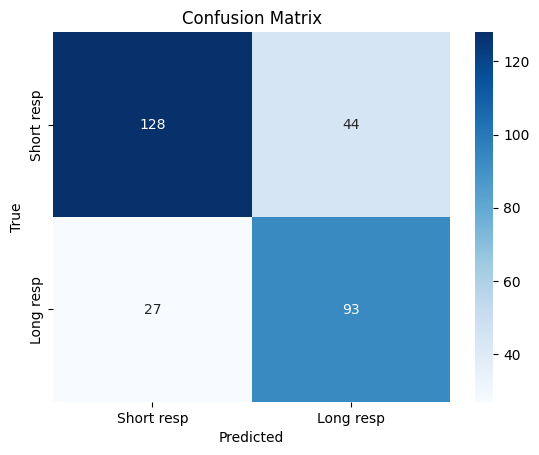

In [28]:
results = cross_validate(
    full_pipe, x, y,
    cv=skf,
    scoring=['roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1,
    return_estimator=True
)

print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}\n")

target_names = ['Short resp', 'Long resp']

y_pred = cross_val_predict(
    full_pipe, x, y, 
    cv=skf,
    n_jobs=-1
)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Check how many genes overlap between folds

In [29]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    coefs = full_pipe['clf'].coef_[0]
    mask = coefs != 0
    selected_per_fold.append(set(names[mask]))

gex_per_fold = [{f for f in fold if f.startswith('remainder__')} for fold in selected_per_fold]

common_gex = set.intersection(*gex_per_fold)
union_gex  = set.union(*gex_per_fold)
sizes_gex  = [len(s) for s in gex_per_fold]

print(f"GEX per-fold sizes : {sizes_gex}")
print(f"GEX in all folds   : {len(common_gex)} → {common_gex}")
print(f"GEX union size     : {len(union_gex)}")
print(f"GEX stability ratio: {len(common_gex) / max(1, min(sizes_gex)):.2f}")

GEX per-fold sizes : [15, 15, 14, 12, 14]
GEX in all folds   : 9 → {'remainder__PKIG', 'remainder__MCOLN2', 'remainder__FGFR1OP2', 'remainder__STAT1', 'remainder__HEXD', 'remainder__HAPLN3', 'remainder__C1DP5', 'remainder__GRIPAP1', 'remainder__CLEC2B'}
GEX union size     : 18
GEX stability ratio: 0.75


Check genes overlap with KEGG-VCELLS genes

In [ ]:
with open("../dataset/additional/combine-kegg-vcells.txt") as f:
    kegg_vcells = {g.strip() for g in f.read().split(",")}

GEX_COLS_KEGG = [g for g in common_gex if g in kegg_vcells]

print(f"combine-kegg-vcells genes : {len(kegg_vcells)}")
print(f"GEX_COLS genes   : {len(common_gex)}")
print(f"Overlap (GEX_COLS_KEGG)   : {len(GEX_COLS_KEGG)}")

combine-kegg-vcells genes : 174
GEX_COLS_FILTERED genes   : 9
Overlap (GEX_COLS_KEGG)   : 0


Save best model (across different train-test splits) for explanability

In [31]:
print(results['test_roc_auc'])
print(results['test_f1'])

[0.79880952 0.84285714 0.82352941 0.86764706 0.80637255]
[0.69230769 0.63636364 0.76923077 0.78571429 0.71698113]


In [33]:
import joblib
import os

fold_idx = 4    # choose fold 4 model

best_pipeline = results["estimator"][fold_idx] 

os.makedirs(f"../saved-models/", exist_ok=True)
joblib.dump(best_pipeline, f'../saved-models/tcga-model.joblib')

['../saved-models/tcga-model.joblib']

In [34]:
splits = list(skf.split(x, y))
train_idx, test_idx = splits[fold_idx]   

x_train = x.iloc[train_idx]
x_test  = x.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

x_train.to_csv(f"../dataset/created/x_train_tcga.csv", index=False)
x_test.to_csv(f"../dataset/created/x_test_tcga.csv", index=False)
y_train.to_csv(f"../dataset/created/y_train_tcga.csv", index=False)
y_test.to_csv(f"../dataset/created/y_test_tcga.csv", index=False)